
# Lab-7

**Name:** Abdul Qudoos 
**CMS:** 023-24-0233  
**Section:** G  
**GitHub Profile:**(https://github.com/abdulqudoos181005)
**Kaggle Profile:** https://www.kaggle.com/abdulqudoos7860 
 

## task-A:

### 1.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Load datasets
spam_df = pd.read_csv("spam.csv", encoding='latin-1')
tweets_df = pd.read_csv("Tweets.csv", encoding='latin-1')

# -----------------------------
# Spam Dataset
# -----------------------------

print("SPAM DATASET")
print("Shape:", spam_df.shape)

print("\nFirst 5 rows:")
display(spam_df.head())
# Keep only the two useful columns from SMS dataset

spam_df = spam_df.iloc[:, :2]
spam_df.columns = ["label", "message"]

print(spam_df.head())
print(spam_df.columns)


spam_counts = spam_df["label"].value_counts()
spam_percent = spam_df["label"].value_counts(normalize=True) * 100

spam_balance = pd.DataFrame({
    "Count": spam_counts,
    "Percentage": spam_percent.round(2)
})

print(spam_balance)

# Keep only positive and negative tweets

tweets_df = tweets_df[
    tweets_df["airline_sentiment"].isin(["positive", "negative"])
].copy()

print("Twitter dataset after removing neutral tweets:")
print(tweets_df.shape)

print("\nClass balance:")
print(tweets_df["airline_sentiment"].value_counts())

print("\nClass percentages:")
print(
    tweets_df["airline_sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


SPAM DATASET
Shape: (5572, 5)

First 5 rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Index(['label', 'message'], dtype='str')
       Count  Percentage
label                   
ham     4825       86.59
spam     747       13.41
Twitter dataset after removing neutral tweets:
(11541, 15)

Class balance:
airline_sentiment
negative    9178
positive    2363
Name: count, dtype: int64

Class percentages:
airline_sentiment
negative    79.53
positive    20.47
Name: proportion, dtype: float64


Explaination: **Spam:** Spam dataset: Each row represents one SMS message. The target variable is label, which contains two classes: ham and spam. Therefore, this is a binary classification problem because the model must choose between only two possible classes.
**Sentiment:** Twitter dataset: Each row represents one airline-related tweet. The target is airline_sentiment, and we keep only positive and negative tweets. Therefore, it becomes a binary classification problem where the model predicts whether a tweet is positive or negative.


### 2.
#### **Spam:**
The spam model can help decide whether an incoming SMS should be treated as spam or a normal message. This can help automatically filter unwanted messages from a user's inbox. It is binary classification because the output is either spam or ham.

#### **Sentiment:**
The sentiment model can help determine whether a customer's airline-related tweet expresses a positive or negative opinion. This can help airlines understand customer feedback automatically. It is binary classification because only positive and negative tweets are used.


### 3.

In [9]:
spam_df["message"] = spam_df["message"].astype(str).str.lower()


spam_df["message"] = spam_df["message"].str.replace(
    r"[^\w\s]", "", regex=True
)

print(spam_df.head())

  label                                            message
0   ham  go until jurong point crazy available only in ...
1   ham                            ok lar joking wif u oni
2  spam  free entry in 2 a wkly comp to win fa cup fina...
3   ham        u dun say so early hor u c already then say
4   ham  nah i dont think he goes to usf he lives aroun...


### 4.


In [11]:
# Encode labels
spam_df["label_encoded"] = spam_df["label"].map({
    "ham": 0,
    "spam": 1
})

# Separate input and target
X_spam = spam_df["message"]
y_spam = spam_df["label_encoded"]

# Train-test split
X_train_spam, X_test_spam, y_train_spam, y_test_spam = train_test_split(
    X_spam,
    y_spam,
    test_size=0.20,
    random_state=42,
    stratify=y_spam
)

print("Training samples:", len(X_train_spam))
print("Testing samples:", len(X_test_spam))

# Create CountVectorizer
spam_vectorizer = CountVectorizer()

# IMPORTANT:
# Fit only on training data
X_train_spam_vec = spam_vectorizer.fit_transform(X_train_spam)

# Only transform test data
X_test_spam_vec = spam_vectorizer.transform(X_test_spam)

print("Training matrix shape:", X_train_spam_vec.shape)
print("Testing matrix shape:", X_test_spam_vec.shape)

print("Vocabulary size:", len(spam_vectorizer.get_feature_names_out()))

Training samples: 4457
Testing samples: 1115
Training matrix shape: (4457, 7701)
Testing matrix shape: (1115, 7701)
Vocabulary size: 7701


explanation:The vectorizer must be fitted only on training data because fitting it on the complete dataset would allow information from the test set to influence the model. This causes data leakage and can make the evaluation less reliable.

### 5.


Spam Detection Results
----------------------
Accuracy : 0.9839
Precision: 0.9645
Recall   : 0.9128
F1 Score : 0.9379
Confusion Matrix:
[[961   5]
 [ 13 136]]


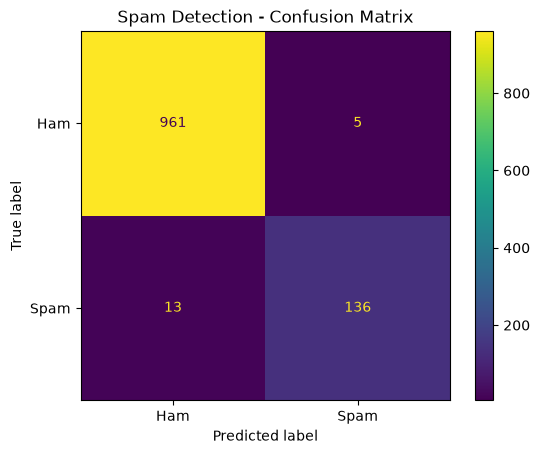

In [12]:
# Create model
spam_model = MultinomialNB()

# Train
spam_model.fit(X_train_spam_vec, y_train_spam)

# Predict
spam_predictions = spam_model.predict(X_test_spam_vec)

# Metrics
spam_accuracy = accuracy_score(y_test_spam, spam_predictions)
spam_precision = precision_score(y_test_spam, spam_predictions)
spam_recall = recall_score(y_test_spam, spam_predictions)
spam_f1 = f1_score(y_test_spam, spam_predictions)

print("Spam Detection Results")
print("----------------------")
print("Accuracy :", round(spam_accuracy, 4))
print("Precision:", round(spam_precision, 4))
print("Recall   :", round(spam_recall, 4))
print("F1 Score :", round(spam_f1, 4))

cm_spam = confusion_matrix(y_test_spam, spam_predictions)

print("Confusion Matrix:")
print(cm_spam)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_spam,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("Spam Detection - Confusion Matrix")
plt.show()

The confusion matrix shows how many ham messages and spam messages were correctly or incorrectly classified. Accuracy gives the overall correctness, while precision and recall provide more specific information about spam predictions.


### 6.
In spam filtering, a false positive can be more harmful because a real message may be incorrectly marked as spam and hidden from the user. A false negative allows a spam message to reach the inbox, which is usually inconvenient but does not necessarily remove an important message. Therefore, I would prioritize precision if avoiding the loss of genuine messages is the main concern. However, the final choice depends on how the spam filter is intended to be used.


### 7.


In [13]:
# Get vocabulary
words = spam_vectorizer.get_feature_names_out()

# Class order:
# 0 = ham
# 1 = spam

ham_log_probs = spam_model.feature_log_prob_[0]
spam_log_probs = spam_model.feature_log_prob_[1]

# Difference
difference = spam_log_probs - ham_log_probs

# 15 strongest spam-associated words
spam_indices = np.argsort(difference)[-15:][::-1]

# 15 strongest ham-associated words
ham_indices = np.argsort(difference)[:15]

print("15 words most associated with SPAM:")
for i in spam_indices:
    print(words[i], round(difference[i], 4))

print("\n15 words most associated with HAM:")
for i in ham_indices:
    print(words[i], round(difference[i], 4))

15 words most associated with SPAM:
claim 5.532
prize 5.1977
150p 4.9855
tone 4.8283
18 4.7158
cs 4.667
guaranteed 4.6157
500 4.6157
1000 4.5045
uk 4.4439
150ppm 4.3454
awarded 4.3104
www 4.2863
collection 4.2362
rate 4.197

15 words most associated with HAM:
gt -4.5864
lt -4.5709
he -4.1033
lor -3.8894
da -3.8894
she -3.8581
later -3.784
ì_ -3.5436
ll -3.3349
doing -3.2985
say -3.2703
really -3.256
ask -3.256
home -3.2487
anything -3.2414


The words with the largest positive differences are more strongly associated with spam, while words with the most negative differences are more strongly associated with ham. The results can be compared with our intuition about typical promotional or suspicious SMS messages.

### 8.